## 📌 Extracción(E - Extract)

In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

datos = pd.read_json(url)
datos.head(3)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [186]:
columnas_json = ['customer', 'phone', 'internet', 'account']

# Lista para guardar los dataframes expandidos
dfs_expandidos = []

for col in columnas_json:
    # Expandimos la columna y le añadimos un prefijo para saber de dónde viene (opcional)
    temp_df = pd.json_normalize(datos[col])
    dfs_expandidos.append(temp_df)

# Unimos todo: el customerID, el Churn y todas las nuevas columnas
datos_final = pd.concat([datos[['customerID', 'Churn']]] + dfs_expandidos, axis=1)

# Ver el resultado
datos_final.info()
datos_final.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## 🔧 Transformación (T - Transform)

In [187]:
# Convertir a numérico, los errores se convierten en NaN
datos_final['Charges.Total'] = pd.to_numeric(datos_final['Charges.Total'], errors='coerce')

# Verificar si aparecieron nulos tras la conversión
print(f"Nulos en Charges.Total: {datos_final['Charges.Total'].isnull().sum()}")

# Llenar esos nulos con 0 (ya que suelen ser clientes nuevos sin cargos todavía)
datos_final['Charges.Total'] = datos_final['Charges.Total'].fillna(0)

Nulos en Charges.Total: 11


In [188]:
# Ver cuántos "Yes" y "No" hay
print(datos_final['Churn'].value_counts())

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


In [189]:
# Reemplazar strings vacíos por NaN y luego eliminarlos
datos_final['Churn'] = datos_final['Churn'].replace('', np.nan)
datos_final.dropna(subset=['Churn'], inplace=True)

# Confirmar que ahora solo tenemos "Yes" y "No"
print(datos_final['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [190]:
# Contar duplicados
duplicados = datos_final.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

# Si hay, los eliminamos:
if duplicados > 0:
    datos_final = datos_final.drop_duplicates()

Registros duplicados: 0


In [191]:
# Aplicar strip() a todas las columnas tipo object (strings)
columnas_object = datos_final.select_dtypes(include=['object']).columns

for col in columnas_object:
    datos_final[col] = datos_final[col].str.strip()

# Identificar automáticamente todas las columnas categóricas (tipo 'object')
# Excluimos 'customerID' porque es un identificador único, no una categoría
columnas_categoricas = datos_final.select_dtypes(include=['object']).columns.drop('customerID')

# Iterar y mostrar los valores únicos de cada una
print("Verificación de Consistencia de Categorías")
for col in columnas_categoricas:
    unicos = datos_final[col].unique()
    print(f"\nColumna: {col} ({len(unicos)} categorías)")
    print(unicos)

Verificación de Consistencia de Categorías

Columna: Churn (2 categorías)
['No' 'Yes']

Columna: gender (2 categorías)
['Female' 'Male']

Columna: Partner (2 categorías)
['Yes' 'No']

Columna: Dependents (2 categorías)
['Yes' 'No']

Columna: PhoneService (2 categorías)
['Yes' 'No']

Columna: MultipleLines (3 categorías)
['No' 'Yes' 'No phone service']

Columna: InternetService (3 categorías)
['DSL' 'Fiber optic' 'No']

Columna: OnlineSecurity (3 categorías)
['No' 'Yes' 'No internet service']

Columna: OnlineBackup (3 categorías)
['Yes' 'No' 'No internet service']

Columna: DeviceProtection (3 categorías)
['No' 'Yes' 'No internet service']

Columna: TechSupport (3 categorías)
['Yes' 'No' 'No internet service']

Columna: StreamingTV (3 categorías)
['Yes' 'No' 'No internet service']

Columna: StreamingMovies (3 categorías)
['No' 'Yes' 'No internet service']

Columna: Contract (3 categorías)
['One year' 'Month-to-month' 'Two year']

Columna: PaperlessBilling (2 categorías)
['Yes' 'No']

Co

In [192]:
# Aplicar strip() a todas las columnas tipo object (strings)
columnas_object = datos_final.select_dtypes(include=['object']).columns

for col in columnas_object:
    datos_final[col] = datos_final[col].str.strip()

# Ahora revisa si hay categorías extrañas o inconsistentes
for col in ['gender', 'InternetService', 'Contract', 'PaymentMethod']:
    print(f"\nValores únicos en {col}:")
    print(datos_final[col].unique())


Valores únicos en gender:
['Female' 'Male']

Valores únicos en InternetService:
['DSL' 'Fiber optic' 'No']

Valores únicos en Contract:
['One year' 'Month-to-month' 'Two year']

Valores únicos en PaymentMethod:
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [193]:
import re

# Limpieza inteligente de NOMBRES de columnas
nuevos_nombres = []
for col in datos_final.columns:
    # Si la columna ya tiene el formato SeniorCitizen (mayúscula intermedia), solo limpiamos puntos/espacios
    if re.search(r'[a-z][A-Z]', col):
        nombre_limpio = col.replace('.', '').replace(' ', '')
    else:
      mapeo_especifico = {'tenure': 'Tenure', 'gender': 'Gender'}

      # Si la columna está en el mapa, usa el valor corregido;
      # de lo contrario, aplica la limpieza de puntos y espacios.
      nombre_limpio = mapeo_especifico.get(col, col.replace('.', '').replace(' ', ''))
    nuevos_nombres.append(nombre_limpio)

datos_final.columns = nuevos_nombres

# Identificar automáticamente las columnas categóricas con los NUEVOS nombres
# Excluimos Customerid y Churn (si ya es numérica)
columnas_categoricas = datos_final.select_dtypes(include=['object']).columns.drop(['Customerid'], errors='ignore')

# Normalizar los VALORES dentro de las celdas (Sin destruir siglas como DSL)
for col in columnas_categoricas:
    datos_final[col] = (
        datos_final[col]
        .astype(str)
        .str.strip()
        # Usamos una función lambda para capitalizar solo la primera letra
        # sin afectar el resto del contenido (mantiene DSL, Fiber Optic -> Fiber_Optic)
        .apply(lambda x: x[0].upper() + x[1:] if len(x) > 0 else x)
        .str.replace(r'\s+', '_', regex=True)
    )

print("Columnas actuales:", datos_final.columns.tolist())
datos_final.head()

Columnas actuales: ['customerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'ChargesMonthly', 'ChargesTotal']


,customerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One_year,Yes,Mailed_check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed_check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber_optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic_check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber_optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic_check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber_optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed_check,83.9,267.40


In [194]:
# Calcular la facturación diaria basada en la mensual
# Usamos Charges_monthly o el nombre que tenga tu columna tras la normalización
# En tu caso, tras el proceso anterior, debería ser 'Charges_monthly' o 'Charges_Monthly'
nombre_col_mensual = 'ChargesMonthly' if 'ChargesMonthly' in datos_final.columns else 'ChargesMonthly'

datos_final['CuentasDiarias'] = (datos_final[nombre_col_mensual] / 30).round(2)

# Verificamos la creación de la columna
print(datos_final[['customerID', nombre_col_mensual, 'CuentasDiarias']].head())

   customerID  ChargesMonthly  CuentasDiarias
0  0002-ORFBO            65.6            2.19
1  0003-MKNFE            59.9            2.00
2  0004-TLHLJ            73.9            2.46
3  0011-IGKFF            98.0            3.27
4  0013-EXCHZ            83.9            2.80


In [195]:
# Columnas que son estrictamente binarias (Yes/No)
cols_binarias_puras = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in cols_binarias_puras:
    # Aseguramos que coincida con el formato que traemos (Capitalizado)
    datos_final[col] = datos_final[col].map({'Yes': 1, 'No': 0})

# Columnas con tercera opción (Yes, No, No_internet/phone_service)
cols_con_tercera_opcion = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport'
]

# Opción A: Mapeo manual si quieres mantener la distinción
# (Usamos 1 para Yes, 0 para No, y -1 o una categoría aparte para el resto)
for col in cols_con_tercera_opcion:
    print(f"Valores originales en {col}:", datos_final[col].unique())

Valores originales en MultipleLines: ['No' 'Yes' 'No_phone_service']
Valores originales en OnlineSecurity: ['No' 'Yes' 'No_internet_service']
Valores originales en OnlineBackup: ['Yes' 'No' 'No_internet_service']
Valores originales en DeviceProtection: ['No' 'Yes' 'No_internet_service']
Valores originales en TechSupport: ['Yes' 'No' 'No_internet_service']


## 📊 Carga y análisis (L - Load & Analysis)

In [196]:
# Resumen estadístico general de las variables numéricas
# Incluimos ChargesMonthly (tal cual), Tenure, ChargesTotal y CuentasDiarias
columnas_numericas = ['Tenure', 'ChargesMonthly', 'ChargesTotal', 'CuentasDiarias']
resumen_general = datos_final[columnas_numericas].describe().round(2)

print("Resumen Estadístico General")
print(resumen_general)

# Análisis Comparativo: Clientes Leales vs. Evasión (Churn)
# Esto nos dirá si los que se van pagan más en promedio
comparativa_churn = datos_final.groupby('Churn')[columnas_numericas].mean().round(2)

print("\nMedia de Gastos y Antigüedad por Estado de Churn")
print(comparativa_churn)

Resumen Estadístico General
        Tenure  ChargesMonthly  ChargesTotal  CuentasDiarias
count  7043.00         7043.00       7043.00         7043.00
mean     32.37           64.76       2279.73            2.16
std      24.56           30.09       2266.79            1.00
min       0.00           18.25          0.00            0.61
25%       9.00           35.50        398.55            1.18
50%      29.00           70.35       1394.55            2.34
75%      55.00           89.85       3786.60            2.99
max      72.00          118.75       8684.80            3.96

Media de Gastos y Antigüedad por Estado de Churn
       Tenure  ChargesMonthly  ChargesTotal  CuentasDiarias
Churn                                                      
0       37.57           61.27       2549.91            2.04
1       17.98           74.44       1531.80            2.48


In [197]:
# Ver la distribución de clientes Senior y servicios de Internet
print("\nDistribución de SeniorCitizen:")
print(datos_final['SeniorCitizen'].value_counts(normalize=True).round(4) * 100)
print("\nDistribución de InternetService:")
print(datos_final['InternetService'].value_counts())


Distribución de SeniorCitizen:
SeniorCitizen
0    83.79
1    16.21
Name: proportion, dtype: float64

Distribución de InternetService:
InternetService
Fiber_optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


/tmp/ipykernel_706/2731274502.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datos_final, x='Churn', palette='viridis')


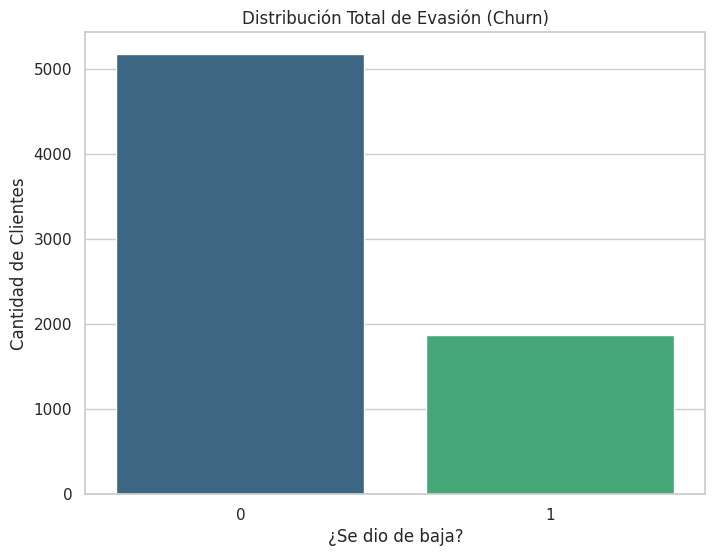

Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [198]:
plt.figure(figsize=(8, 6))
# Gráfico de barras simple para ver la proporción
sns.countplot(data=datos_final, x='Churn', palette='viridis')
plt.title('Distribución Total de Evasión (Churn)')
plt.xlabel('¿Se dio de baja?')
plt.ylabel('Cantidad de Clientes')
plt.show()

# Proporción en porcentaje
print(datos_final['Churn'].value_counts(normalize=True).round(4) * 100)

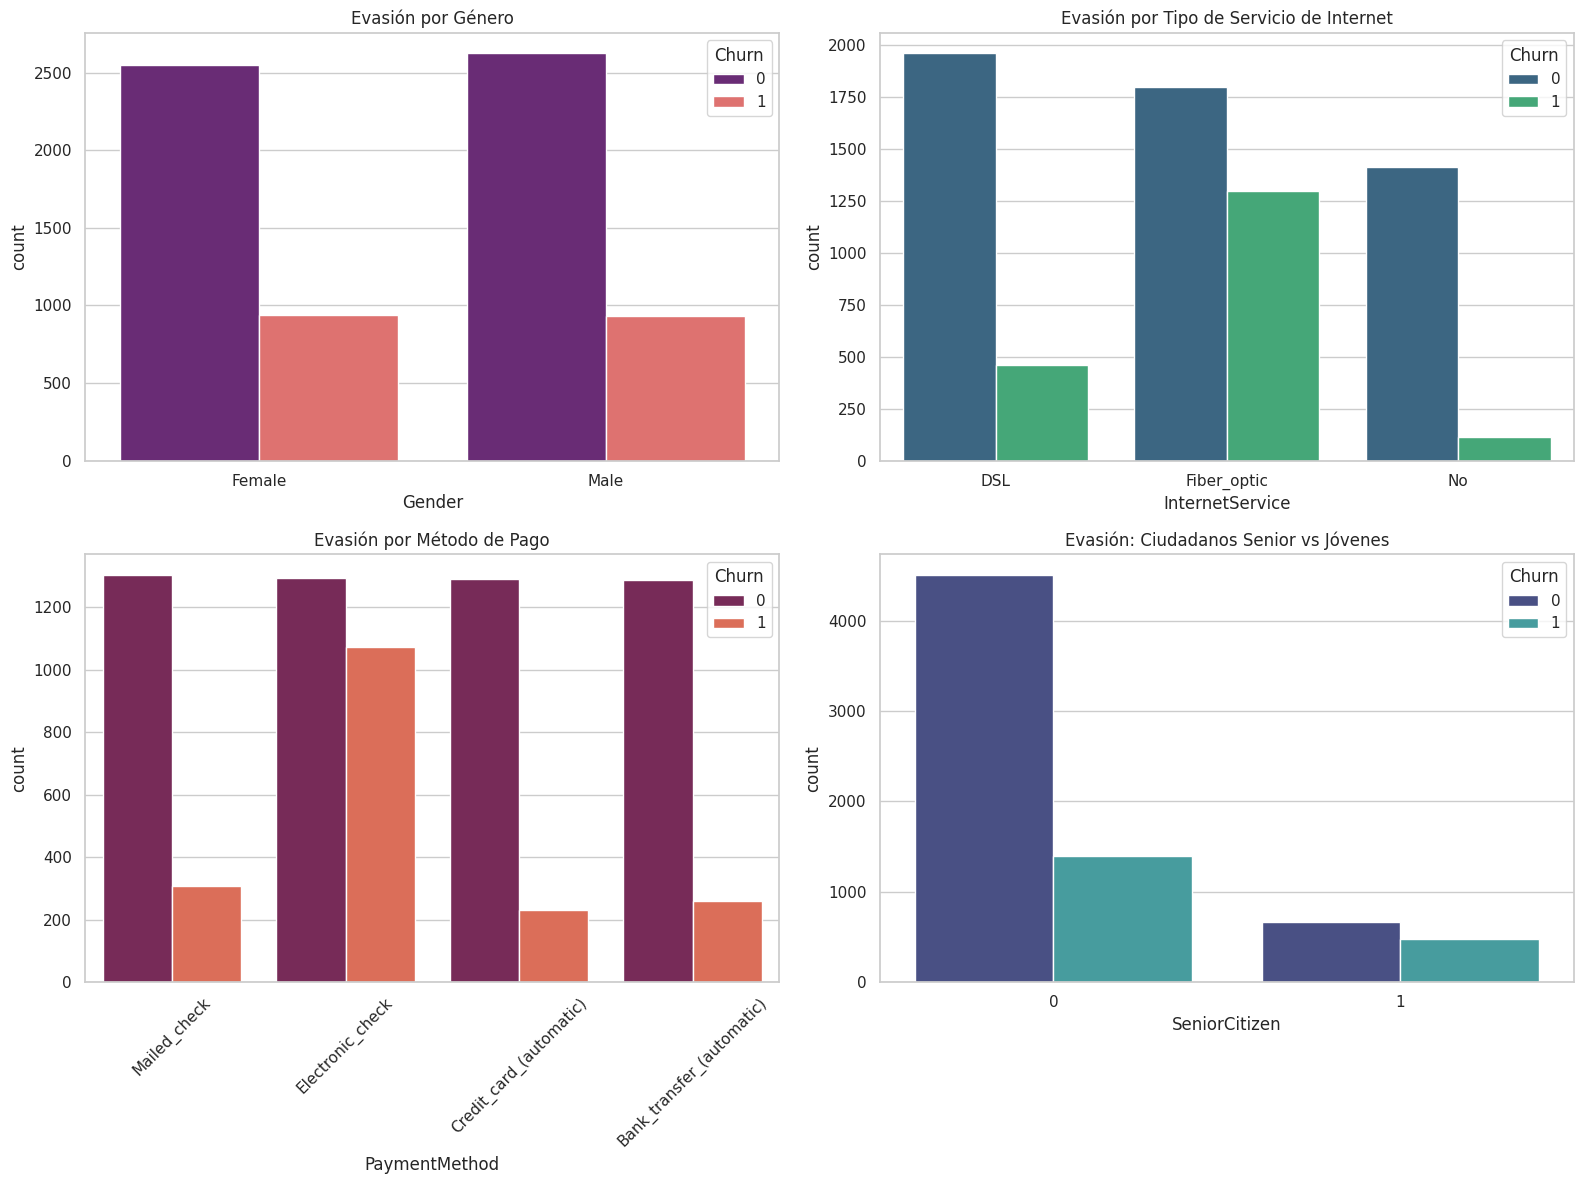

In [199]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Género vs Churn
sns.countplot(data=datos_final, x='Gender', hue='Churn', ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Evasión por Género')

# InternetService vs Churn (Punto Crítico)
sns.countplot(data=datos_final, x='InternetService', hue='Churn', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Evasión por Tipo de Servicio de Internet')

# PaymentMethod vs Churn
sns.countplot(data=datos_final, x='PaymentMethod', hue='Churn', ax=axes[1, 0], palette='rocket')
plt.setp(axes[1, 0].get_xticklabels(), rotation=45)
axes[1, 0].set_title('Evasión por Método de Pago')

# SeniorCitizen vs Churn
sns.countplot(data=datos_final, x='SeniorCitizen', hue='Churn', ax=axes[1, 1], palette='mako')
axes[1, 1].set_title('Evasión: Ciudadanos Senior vs Jóvenes')

plt.tight_layout()
plt.show()

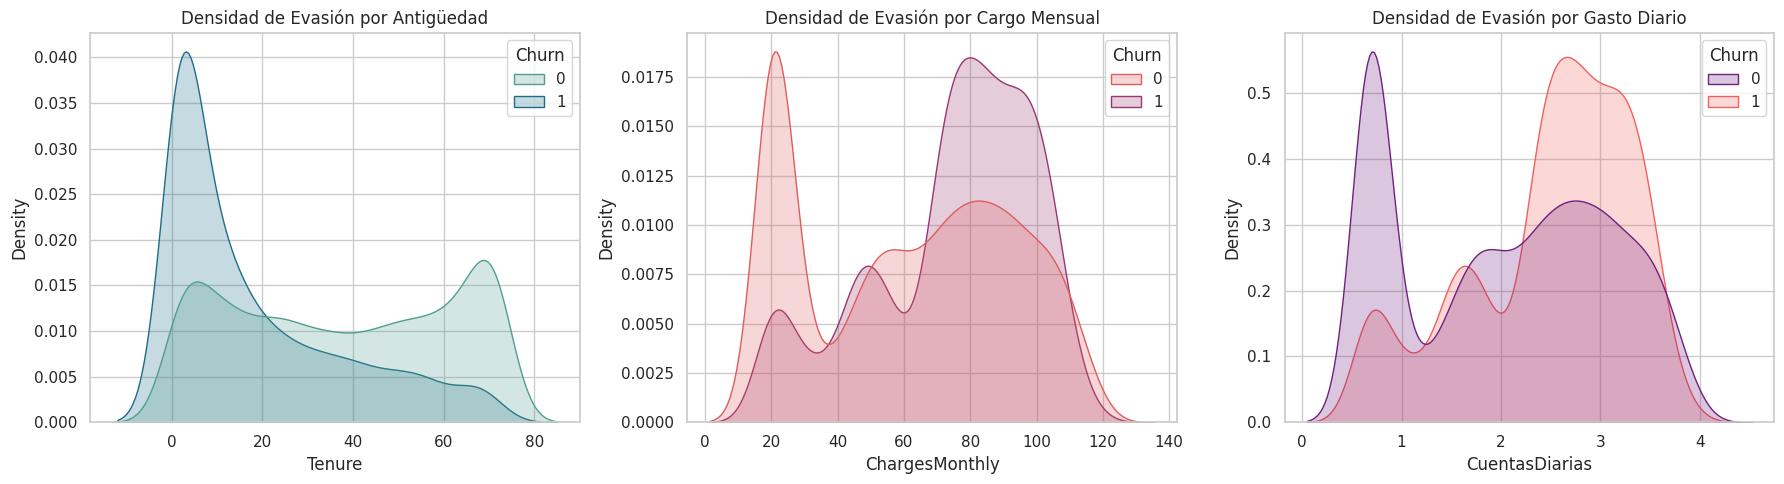

In [200]:
# Configurar el lienzo
plt.figure(figsize=(18, 5))

# Distribución de Tenure (Antigüedad)
plt.subplot(1, 3, 1)
sns.kdeplot(data=datos_final, x='Tenure', hue='Churn', fill=True, common_norm=False, palette='crest')
plt.title('Densidad de Evasión por Antigüedad')

# Distribución de ChargesMonthly (Cargos Mensuales)
plt.subplot(1, 3, 2)
sns.kdeplot(data=datos_final, x='ChargesMonthly', hue='Churn', fill=True, common_norm=False, palette='flare')
plt.title('Densidad de Evasión por Cargo Mensual')

# Distribución de CuentasDiarias (Impacto Diario)
plt.subplot(1, 3, 3)
sns.kdeplot(data=datos_final, x='CuentasDiarias', hue='Churn', fill=True, common_norm=False, palette='magma')
plt.title('Densidad de Evasión por Gasto Diario')

plt.tight_layout()
plt.show()

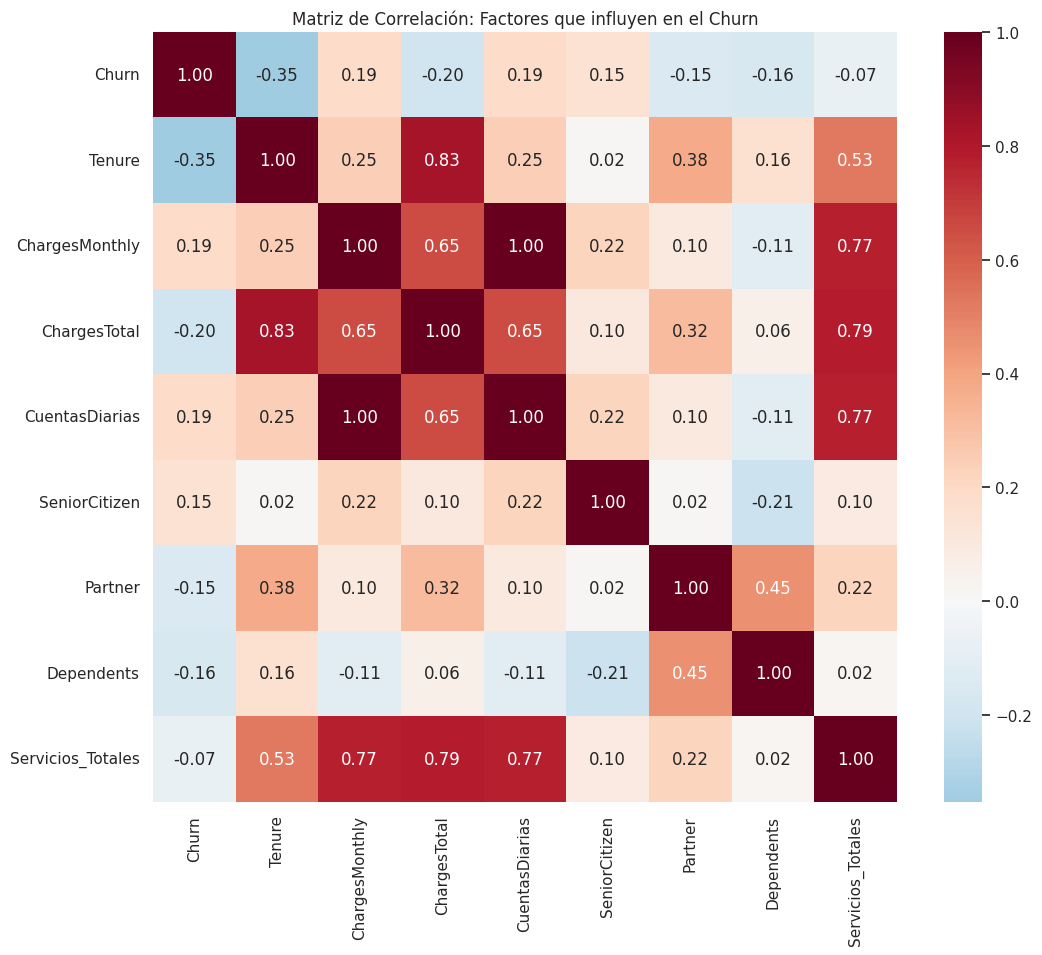

In [201]:
# Crear métrica de volumen de servicios (contamos los 'Yes' en servicios clave)
servicios = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Sumamos 1 si el valor es 'Yes' (ajustado a tu limpieza de datos)
datos_final['Servicios_Totales'] = datos_final[servicios].apply(lambda x: x == 'Yes').sum(axis=1)

# Seleccionar variables para el mapa de calor
cols_corr = ['Churn', 'Tenure', 'ChargesMonthly', 'ChargesTotal',
             'CuentasDiarias', 'SeniorCitizen', 'Partner', 'Dependents', 'Servicios_Totales']

corr_matrix = datos_final[cols_corr].corr()

# Graficar

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Matriz de Correlación: Factores que influyen en el Churn')
plt.show()

# Informe de Análisis de Evasión de Clientes (Churn)
## **Introducción**
El objetivo de este análisis es estudiar el fenómeno de evasión de clientes (Churn) en una empresa de telecomunicaciones, con el propósito de identificar los factores que influyen en que los clientes abandonen el servicio. La evasión de clientes representa un problema crítico para cualquier empresa de servicios, ya que implica la pérdida directa de ingresos y aumenta los costos de adquisición de nuevos clientes.

Para este estudio se analizaron 7,043 registros de clientes, evaluando variables relacionadas con el comportamiento de consumo, antigüedad del cliente, tipo de contrato, servicios contratados, métodos de pago y características demográficas.

Mediante análisis exploratorio de datos (EDA) y visualizaciones, se buscó identificar patrones relevantes que permitan comprender qué variables influyen con mayor peso en la probabilidad de abandono.

El objetivo final es generar insights accionables que permitan desarrollar estrategias para mejorar la retención de clientes y reducir la tasa de churn.
## **Limpieza y Tratamiento de Datos**
Antes de realizar el análisis, fue necesario llevar a cabo un proceso de preparación y limpieza de datos para garantizar la calidad de la información utilizada.

En primer lugar, se realizó la importación del dataset en el entorno de análisis y se verificó la estructura general de los datos, identificando tipos de variables, cantidad de registros y posibles valores faltantes.
Posteriormente se aplicaron los siguientes pasos:

-	Conversión de tipos de datos, especialmente en variables numéricas como cargos totales o antigüedad del cliente.

-	Tratamiento de valores faltantes, eliminando o corrigiendo registros incompletos que podían afectar el análisis.

-	Transformación de variables categóricas, permitiendo su análisis mediante conteos y visualizaciones.

-	Creación de variables derivadas, como el cálculo de gasto diario a partir de los cargos mensuales, con el fin de analizar con mayor precisión el comportamiento de consumo de los clientes.

-	Verificación de consistencia de datos, asegurando que variables relacionadas entre sí mantuvieran coherencia lógica.
Este proceso permitió obtener un conjunto de datos limpio y estructurado, listo para el análisis exploratorio.

## **Análisis Exploratorio de Datos (EDA)**
El análisis exploratorio se centró en identificar patrones en la evasión de clientes a partir de variables numéricas, categóricas y correlaciones entre variables.

### **Análisis descriptivo general**
El conjunto de datos analizado contiene 7,043 clientes. La antigüedad promedio de los clientes es de aproximadamente 32 meses, mientras que el gasto mensual promedio es de 64.76 unidades monetarias.

Al comparar los clientes que permanecen con los que abandonan el servicio, se observan diferencias importantes:

-	Los clientes que permanecen tienen una antigüedad promedio de 37.57 meses.

-	Los clientes que abandonan el servicio presentan una antigüedad promedio de 17.98 meses.

Esto indica que la evasión ocurre principalmente en clientes relativamente nuevos, especialmente durante los primeros meses de servicio.

Además, los clientes que abandonan el servicio presentan un gasto mensual promedio mayor (74.44) en comparación con los clientes que permanecen (61.27). Este resultado sugiere que la empresa está perdiendo clientes de alto valor económico.

**Distribución de clientes por servicios**

El análisis de los tipos de servicio de internet muestra que:

-	Fiber optic es el servicio con mayor número de clientes.

-	DSL ocupa el segundo lugar.

-	Un grupo menor de clientes no posee servicio de internet.

Sin embargo, el servicio de fibra óptica presenta la mayor tasa de evasión, lo cual sugiere que el costo del servicio o la percepción de valor pueden estar influyendo en la decisión de cancelación.

**Contratos y evasión**

- Uno de los factores más determinantes identificados en el análisis es el tipo de contrato.

- Los clientes con contratos mes a mes presentan la mayor proporción de cancelaciones, mientras que los contratos de uno o dos años muestran niveles de retención significativamente más altos.

- Esto indica que los contratos de mayor duración funcionan como un mecanismo natural de retención.

**Variables demográficas**

El análisis de variables demográficas muestra que:

-	El género no presenta diferencias significativas en la tasa de evasión.

-	Los adultos mayores (SeniorCitizen) presentan una mayor propensión al churn en comparación con los clientes más jóvenes.

-	Los clientes que tienen pareja o dependientes presentan menores niveles de evasión, lo que sugiere que los vínculos familiares generan mayor estabilidad en el servicio.

### **Análisis de variables numéricas**
El análisis de variables numéricas revela patrones claros:

**Antigüedad del cliente (Tenure)**

- La evasión se concentra principalmente en los primeros meses de servicio, con un pico significativo cerca del inicio del contrato. A medida que aumenta la antigüedad del cliente, la probabilidad de abandono disminuye de forma considerable.

- Esto indica la existencia de una barrera crítica entre los 18 y 20 meses, después de la cual los clientes tienden a permanecer por periodos más largos.

**Cargos mensuales**

- Los clientes con cargos mensuales elevados presentan mayor probabilidad de abandonar el servicio. En particular, se observa una concentración de churn en el rango de 70 a 110 unidades monetarias mensuales.
Por el contrario, los clientes con cargos más bajos presentan una mayor estabilidad.

**Gasto diario**

- El análisis del gasto diario muestra un comportamiento similar al de los cargos mensuales. La probabilidad de evasión aumenta significativamente cuando el gasto diario supera aproximadamente 2.30 unidades monetarias.

**Análisis de correlación**

El análisis de correlación entre variables permite identificar relaciones relevantes:

-	Tenure y Churn presentan una correlación negativa moderada (-0.35), indicando que a mayor antigüedad, menor probabilidad de abandono.

- ChargesMonthly y gasto diario presentan correlación perfecta (1.00), ya que representan la misma información en escalas distintas.

-	Servicios totales y cargos mensuales presentan correlación alta (0.77), lo que indica que el aumento en servicios contratados incrementa proporcionalmente el costo mensual.

-	Partner y Dependents presentan correlación positiva, reflejando estructuras familiares dentro de la base de clientes.
Estas relaciones ayudan a comprender la dinámica entre valor del cliente, permanencia y probabilidad de evasión.
## **Conclusiones e Insights**
El análisis permitió identificar varios factores clave asociados con la evasión de clientes.

+ En primer lugar, la antigüedad del cliente es el factor más importante para predecir churn. Los clientes que superan aproximadamente los 20 meses de permanencia muestran una probabilidad mucho menor de abandonar el servicio.

+ En segundo lugar, los clientes con mayores cargos mensuales presentan mayor riesgo de evasión, lo que indica que el precio percibido puede estar afectando la satisfacción o la percepción de valor del servicio.

+ También se identificó que los contratos mensuales son el principal foco de cancelaciones, mientras que los contratos de mayor duración presentan niveles de retención mucho más altos.

+ Además, el servicio de fibra óptica concentra una gran proporción de cancelaciones, lo que sugiere que el precio o la experiencia del servicio pueden estar influyendo en la decisión de abandono.

Finalmente, se observó que los clientes con vínculos familiares tienden a ser más estables, lo que abre oportunidades para diseñar planes familiares como estrategia de retención.

## **Recomendaciones Estratégicas**
Con base en los resultados obtenidos, se proponen las siguientes estrategias para reducir la evasión de clientes:
1. Incentivar contratos de largo plazo, ofrecer descuentos o beneficios adicionales para motivar a los clientes con contratos mensuales a migrar hacia contratos de uno o dos años.
2. Implementar estrategias de retención temprana, desarrollar programas de fidelización enfocados en clientes con menos de 12 meses de antigüedad, ya que este periodo presenta el mayor riesgo de abandono.
3. Revisar la estrategia de precios del servicio de fibra óptica y analizar la estructura de costos o mejorar la percepción de valor mediante beneficios adicionales para evitar la cancelación de clientes de alto valor.
4. Crear paquetes de servicios integrados (bundles), diseñar paquetes que combinen varios servicios a un precio reducido, aumentando la dependencia del cliente hacia el ecosistema de servicios.
5. Fomentar métodos de pago automáticos y promover el uso de pagos automáticos mediante tarjeta o transferencia bancaria, ya que estos métodos presentan menores tasas de evasión.
